### 네이버 영화리뷰 감성분석

In [1]:
!curl -L -o ratings_train.txt https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt  # 학습용 데이터 파일 다운로드
!curl -L -o ratings_test.txt  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt   # 테스트용 데이터 파일 다운로드

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 13.95M 100 13.95M   0      0 69.91M      0                              0
100 13.95M 100 13.95M   0      0 69.89M      0                              0
100 13.95M 100 13.95M   0      0 69.84M      0                              0
curl: (3) URL rejected: No host part in the URL
curl: (6) Could not resolve host: xn--ru4bi6eisq
curl: (6) Could not resolve host: xn--2n1bp39av7g
curl: (6) Could not resolve host: xn--pu5bl5s
curl: (6) Could not resolve host: xn--2j1bj1b12ewtu
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100  4.66M 100  4.66M   0      0 54.07M      0     

In [2]:
import pandas as pd
ratings_train_df = pd.read_csv('ratings_train.txt', sep='\t')
ratings_test_df = pd.read_csv('ratings_test.txt', sep='\t')

ratings_train_df.shape, ratings_test_df.shape

((150000, 3), (50000, 3))

In [3]:
ratings_train_df.isna().sum()

id          0
document    5
label       0
dtype: int64

In [4]:
ratings_test_df.isna().sum()

id          0
document    3
label       0
dtype: int64

In [5]:
ratings_train_df = ratings_train_df.dropna(how='any')  # 하나라도 결측치가 있으면 해당 행 삭제 (기본값)
ratings_test_df = ratings_test_df.dropna(how='any')

In [6]:
# 학습 리뷰 문장을 텍스트?테스트? 파일에 저장

In [7]:
ratings_train_df.shape, ratings_test_df.shape

((149995, 3), (49997, 3))

In [8]:
# 데이터 샘플링 (학습시간 단축, 메모리사용량 감안)
ratings_train_df = ratings_train_df.sample(n=50000, random_state=42)
ratings_test_df = ratings_test_df.sample(n=5000, random_state=42)

ratings_train_df.shape, ratings_test_df.shape

((50000, 3), (5000, 3))

In [9]:
# 데이터 전처리 함수 생성
import re
from konlpy.tag import Okt

# 텍스트파일에서 stopwords 리스트 가져오는 함수
def load_stopwords(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        stopwords = [line.strip() for line in f]  # 줄바꿈/공백 제거하여 리스트 생성
    return stopwords

# 파일 경로 받아 불용어 로드하는 함수
ko_stopwords = load_stopwords('ko_stopwords.txt')

# 전처리 함수
def preprocessing(sentence, okt=Okt()):
    sentence = re.sub(r'\n', ' ', sentence)  # 개행문자 (줄바꿈) 제거
    sentence = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣ\s]', ' ', sentence) # 한글 외 문자 제거

    tokens = okt.morphs(sentence, stem = True)  # 형태소 분석(어간추출)

    tokens = [token for token in tokens if token not in ko_stopwords]  # 불용어 제거

    return tokens

In [10]:
sample = '''
    이런 영화 진짜 fantastic!!
    너무 못 만들었다. 
    그런데 감동이다!!!!😻😻😻😻😻
'''

preprocessing(sample)

['이렇다', '영화', '진짜', '너무', '못', '만들다', '감동', '이다']

In [11]:
# 텍스트 전처리하고, 학습/테스트 리스트 생성
from tqdm.auto import tqdm

X_train, y_train, X_test, y_test = [], [], [], []

for index, row in tqdm(ratings_train_df.iterrows()):  # df의 행단위 순회
    doc, label = row['document'], row['label']
    X_train.append(preprocessing(doc))  # X데이터는 전처리 후 수집
    y_train.append(label)

for index, row in tqdm(ratings_test_df.iterrows()):
    doc, label = row['document'], row['label']
    X_test.append(preprocessing(doc))
    y_test.append(label)

print(len(X_train), len(y_train), len(X_test), len(y_test))

0it [00:00, ?it/s]

0it [00:00, ?it/s]

50000 50000 5000 5000


In [12]:
print(X_train[:3])
print(y_train[:3])

print(X_test[:3])
print(y_test[:3])

[['원본', '최고'], ['스릴', '감', '훈훈하다', '영화'], ['굉장하다', '평가', '되다', '영화', '중', '라고', '생각', '함']]
[1, 1, 1]
[['찌다', '여운', '내', '인생', '최고', '미드'], ['기대', '이다'], ['신나다', '없다', '애니']]
[1, 1, 0]


In [13]:
# 토큰화 기반 정수 인코딩 준비 및 시퀀스 변환
from tensorflow.keras.preprocessing.text import Tokenizer  # 텍스트 -> 정수 시퀀스
from tensorflow.keras.preprocessing.sequence import pad_sequences  # 패딩(길이 통일) 도구

vocab_size = 20000  # 단어 사전 크기 (빈도 기준 상위 2만개)

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')  # 사전에 없는 단어는 OOV 처리

tokenizer.fit_on_texts(X_train)  # 학습 데이터로 단어사전(word_index) 학습(생성)
X_train_encoded = tokenizer.texts_to_sequences(X_train)  # 학습 텍스트를 정수 시퀀스로 변환
X_test_encoded = tokenizer.texts_to_sequences(X_test)

print(X_train_encoded[:3])
print(X_test_encoded[:3])

[[8686, 28], [473, 297, 793, 2], [649, 413, 16, 2, 55, 125, 32, 208]]
[[1036, 239, 27, 135, 28, 1473], [224, 9], [1546, 8, 261]]


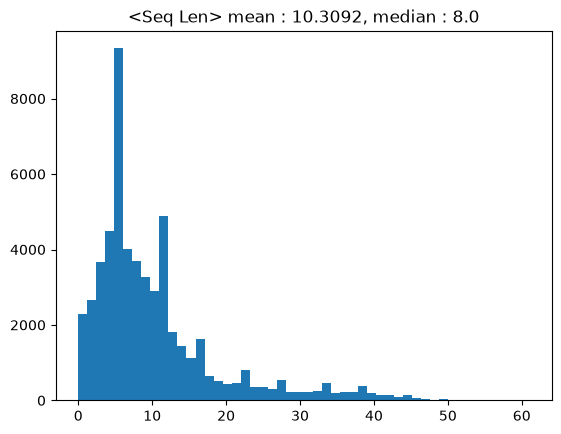

In [14]:
# 패딩 적정 길이 조사
import matplotlib.pyplot as plt
import numpy as np

X_train_len = [len(seq) for seq in X_train]  # 각 샘플 시퀀스 길이 리스트
X_test_len = [len(seq) for seq in X_test]  # 각 샘플 시퀀스 길이 리스트

mean = np.mean(X_train_len + X_test_len)  # 전체(학습+테스트) 시퀀스 길이 평균
median = np.median(X_train_len + X_test_len)  # 전체(학습+테스트) 시퀀스 길이 중앙값

# 히스토그램으로 시각화
plt.hist(X_train_len + X_test_len, bins=50)
plt.title(f'<Seq Len> mean : {mean:.4f}, median : {median}')
plt.show()

In [15]:
max_len = 15  # 모델 입력 최대 시퀀스 길이

X_train_padded = pad_sequences(X_train_encoded, maxlen=max_len)  # max_len 기준 패딩 / 자르기
X_test_padded = pad_sequences(X_test_encoded, maxlen=max_len)    # max_len 기준 패딩 / 자르기

In [16]:
# 정수 시퀀스를 단어로 복원해 사람이 읽을 수 있는 형태로 변환
def decode_sentence(encoded_sentence):
    # 정수 시퀀스를 찾아 해당 인덱스의 단어를 반환 (없으면 _)
    decoded = [tokenizer.index_word.get(n, '_') for n in encoded_sentence]
    return ' '.join(decoded)  # 하나의 문자열로 반환

print(X_train_padded[0])  # 패딩처리 완료된 정수 시퀀스
print(decode_sentence(X_train_padded[0]))  # 원래의 단어 형태로 복원

print(ratings_test_df.iloc[0, 1])  # test 데이터 0번째 데이터 리뷰 (document) 원문
print(X_test_padded[0])
print(decode_sentence(X_test_padded[0]))

[   0    0    0    0    0    0    0    0    0    0    0    0    0 8686
   28]
_ _ _ _ _ _ _ _ _ _ _ _ _ 원본 최고
찐한 여운과 함께...내 인생 최고의 미드
[   0    0    0    0    0    0    0    0    0 1036  239   27  135   28
 1473]
_ _ _ _ _ _ _ _ _ 찌다 여운 내 인생 최고 미드


### 모델 설계

In [17]:
import torch
import torch.nn as nn 

# 양방향 LSTM 분류모델 : 임베딩 -> 양방향 LSTM -> FC 로 감성(이진)분석 logit을 출력하는 모델
class BiLSTMSentimentNet(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()  # nn.Module 초기화
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)  # 임베딩 (0은 학습 영영 주지 않음. 0은 학습 영향 최소화)
        # LSTM 입력 : 임베딩 -> 출력 : 은닉상태 / 양방향 GPU 사용
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)  # GRU 입력 : 임베딩 -> 출력 : 은닉상태
        self.fc = nn.Linear(hidden_dim * 2, 1)  # 정/역방향 마지막 은닉상태 결합(2H) -> 이진 로직 1개

    # 마지막 은닉상태(정/역)을 결합해 문장 표현을 만들고 logit 계산
    def forward(self, x):
        x = self.embedding(x)  # (B, T) -> (B, T, E)
        _, (hidden, _) = self.lstm(x)  # output : (B, T, H), hidden: (L*2, B, H)

        # 양방향 은닉상태 처리
        forward_pass = hidden[-2]  # 정방향 마지막 레이어 은닉상태 (B, H)
        backward_pass = hidden[-1]  # 역방향 마지막 레이어 은닉상태 (B, H)
        hidden_merged = torch.cat((forward_pass, backward_pass), dim=1)  # (B, H) + (B, H) -> (B, 2H)

        output = self.fc(hidden_merged)  # 입력 : 마지막 레이어의 마지막 은닉상태 -> 출력 : (B, 1)
        return output  # sigmoid 적용 전 원시 logit값

model = BiLSTMSentimentNet(vocab_size, embedding_dim=100, hidden_dim=128)
model

BiLSTMSentimentNet(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

In [18]:
# 구조 확인
for name, param in model.named_parameters():
    print(name, param.shape)  # 파라미터 이름과 텐서 shape 출력

embedding.weight torch.Size([20000, 100])
lstm.weight_ih_l0 torch.Size([512, 100])
lstm.weight_hh_l0 torch.Size([512, 128])
lstm.bias_ih_l0 torch.Size([512])
lstm.bias_hh_l0 torch.Size([512])
lstm.weight_ih_l0_reverse torch.Size([512, 100])
lstm.weight_hh_l0_reverse torch.Size([512, 128])
lstm.bias_ih_l0_reverse torch.Size([512])
lstm.bias_hh_l0_reverse torch.Size([512])
fc.weight torch.Size([1, 256])
fc.bias torch.Size([1])


In [19]:
from torchinfo import summary

summary(model)

Layer (type:depth-idx)                   Param #
BiLSTMSentimentNet                       --
├─Embedding: 1-1                         2,000,000
├─LSTM: 1-2                              235,520
├─Linear: 1-3                            257
Total params: 2,235,777
Trainable params: 2,235,777
Non-trainable params: 0

### 모델 학습

In [20]:
import torch.optim as optim

# Pytorch Tensor 형태로 변환 (X데이터는 LongTensor, y데이터는 FloatTensor)
X_train_padded = torch.tensor(X_train_padded, dtype=torch.long)
X_test_padded = torch.tensor(X_test_padded, dtype=torch.long)

# 라벨데이터는 2차원 형태 (unsqueeze(1)로 차원 하나 늘려줌)  (N, ) -> (N, 1)
y_train = torch.tensor(y_train, dtype=torch.float).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float).unsqueeze(1)

print(X_train_padded.shape, X_test_padded.shape)
print(y_train.shape, y_test.shape)

torch.Size([50000, 15]) torch.Size([5000, 15])
torch.Size([50000, 1]) torch.Size([5000, 1])


In [25]:
# 학습 데이터 준비
# DataLoader 구성
from torch.utils.data import random_split, DataLoader, TensorDataset

batch_size = 64
train_size = int(len(X_train_padded) * 0.8)  # 80%는 학습데이터
val_size = len(X_train_padded) - train_size  # 나머지 20%는 검증데이터

# 학습 / 검증 데이터셋 분리 (X, y 데이터 묶은 후에 랜덤 분리) / 테스트 데이터셋 생성
train_dataset, val_dataset = random_split(
    TensorDataset(X_train_padded, y_train), [train_size, val_size]
)
test_dataset = TensorDataset(X_test_padded, y_test)

# 학습용 : 섞어서 배치 생성 / 검증용 : 순서 유지 / 테스트용 : 순서 유지
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(len(train_dataset), len(val_dataset), len(test_dataset))
print(len(train_dataloader), len(val_dataloader), len(test_dataloader))

40000 10000 5000
625 157 79


In [26]:
# 학습 준비
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  #
print(f'device : {device}')

torch.cuda.empty_cache()  # 미사용 캐시메모리 정리 (OOM 대비)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()  # 이진분류 손실함수 (내부 sigmoid 포함)
optimizer = optim.Adam(model.parameters(), lr=0.001)
# 스케줄러 : 검증 손실 계산 정체시 학습률 정차적으로 감소
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,  # 적용할 옵티마이저
    mode='min',  # val_loss가 최소화되는 비율
    factor=0.5,  # 학습률 감소 비율
    patience=3  # 개선이 없을경우 기다림
)

epochs = 100

# 시각화용 지표
train_losses, val_losses, train_accs, val_accs = [], [], [], []

# 조기종료 관련
early_stopping_patience = 5
best_val_loss = float('inf')
early_stopping_counter = 0

device : cpu


In [27]:
from tqdm.auto import tqdm

# 학습
for epoch in tqdm(range(epochs)):
    total_loss, correct, total = 0, 0, 0

    # 학습
    model.train()  # 학습 모드
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device).long(), labels.to(device).float()

        optimizer.zero_grad()  # 이진 기울기 초기화
        output = model(inputs)  # 순전파
        loss = criterion(output, labels)  # 손실 계산
        loss.backward()  # 역전파 : 기울기 계산
        optimizer.step()  # 파라미터 업데이트

        total_loss += loss.detach().item()  # 손실 누적 (그래프 분리하고 수치만 누적)
        p = torch.sigmoid(output)
        pred = (p >= 0.5).float()  # 임계값 기반 예측 (1.0 / 0.0)
        correct += (pred == labels).sum().float().detach().cpu().item()  # 정답 누적 (그래프 분리하고 수치만 누적)
        total += len(labels)
    
    train_loss = total_loss / len(train_dataloader)
    train_losses.append(train_loss)
    train_acc = correct / total
    train_accs.append(train_acc)

    # 검증
    model.eval()  # 평가모드
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():  # 검증시에는 기울기 계산 비활성화
        for val_inputs, val_labels in val_dataloader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)

            output = model(val_inputs)
            loss = criterion(output, val_labels)

            val_loss += loss.item()
            p = torch.sigmoid(output)
            pred = (p >= 0.5).float()
            val_correct += (pred==val_labels).sum().float().detach().cpu().item()
            val_total += len(val_labels)

    val_loss = val_loss / len(val_dataloader)
    val_losses.append(val_loss)
    val_acc = val_correct / val_total
    val_accs.append(val_acc)

    scheduler.step(val_loss)
    lr = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch+1}/{epochs}: Train Loss : {train_loss:.4f}, Train Acc : {train_acc:.4f}, \
    Val Loss : {val_loss:.4f}, Val Acc : {val_acc:.4f}, lr : {lr}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= early_stopping_patience:
            print(f"{epoch + 1}에서 조기종료!")
            break

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100: Train Loss : 0.5045, Train Acc : 0.7423,     Val Loss : 0.4371, Val Acc : 0.7906, lr : 0.001
Epoch 2/100: Train Loss : 0.3756, Train Acc : 0.8294,     Val Loss : 0.4123, Val Acc : 0.8140, lr : 0.001
Epoch 3/100: Train Loss : 0.3013, Train Acc : 0.8685,     Val Loss : 0.4204, Val Acc : 0.8143, lr : 0.001
Epoch 4/100: Train Loss : 0.2270, Train Acc : 0.9076,     Val Loss : 0.4621, Val Acc : 0.8134, lr : 0.001
Epoch 5/100: Train Loss : 0.1516, Train Acc : 0.9420,     Val Loss : 0.5339, Val Acc : 0.8060, lr : 0.001
Epoch 6/100: Train Loss : 0.0948, Train Acc : 0.9666,     Val Loss : 0.6217, Val Acc : 0.8037, lr : 0.0005
Epoch 7/100: Train Loss : 0.0505, Train Acc : 0.9828,     Val Loss : 0.7824, Val Acc : 0.8061, lr : 0.0005
7에서 조기종료!


In [30]:
# 여러 문장을 받아 전처리 -> 인코딩 -> 패딩 -> 모델 추론으로 긍/부정 반환하는 함수
def movie_review_sentimental_analysis(sentences):

    tokens = [preprocessing(sent) for sent in sentences]  # 문장별 전처리
    encoded_sequences = tokenizer.texts_to_sequences(tokens)  # 단어를 정수 시퀀스로 변환
    padded_sequences = pad_sequences(encoded_sequences, maxlen=max_len)  # 고정 길이로 패딩 / 자르기

    X = torch.tensor(padded_sequences, dtype=torch.long).to(device)  # 입력데이터 LongTensor 변환

    model.eval()  # 평가 모드
    with torch.no_grad():  # 추론시 기울기 계산안함
        output = model(X)  # 순전파 (원시 logit 출력)
        p = torch.sigmoid(output)  # 0~1 확률로 변환
        pred = (p >= 0.5).float()  # True면 1.0, False면 0.0

        return ['긍정' if pr == 1 else '부정' for pr in pred]  # pr이 1이면 긍정 .. 예측값 한글로 반환

samples = [
    '이 영화는 대체 왜 만든건지 이해가 안 간다.',
    '오랜만에 감동을 느꼈다~',
    '감독이 생각이 있나?',
    '노래, 연출, 미감 다 완벽했던 작품이었다',
    '주인공에 과몰입해서 봄 ㅜㅜ',
    '이 영화를 영화관에서 보다니 .. 돈이 아깝습니다', 
    '개그코드 넘 안맞음!',
    '재미없는 부분이 없넹 .. '
]

print(movie_review_sentimental_analysis(samples))

['부정', '긍정', '긍정', '긍정', '긍정', '부정', '부정', '부정']
